# NLP Homework 01
### By Sravanth Chowdary Potluri und5uv

#### *Assisted By Github Copilot and ChatGPT




In [1]:
from scipy.special import label
!pip install portalocker

In [2]:
# Install datasets for accessing the datasets
!pip install datasets

If you see the error message like this, that's fine.

```plain
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.
```

# Part I: Natural Language Inference (8 points)

You can refer to the demo code that we used in our class lecture as an example for your implementation. Please pay attention to the difference of the data format and the specific requirements, to make sure your implementation is correct.


For a specific text classification problem, let's consider natural language inference (or sometimes, it is called textual entailment). Despite the name of this task,  the setup of NLI is quite simple: given two texts.

For example, in this section, we will use the [Scifact Entailment](https://huggingface.co/datasets/allenai/scifact_entailment) dataset and build a logistic regression classifier to solve the task. In the dataset, it contains

- Abstract: an abstract from a scientific paper
- Claim: a statement

The task is to predict the scientific relationship between these two texts. There are three relations (labels) of this task

- SUPPORT: the claim is supported by the abstract
- CONTRADICT: the claim is contradicted with the abstract
- NEI: there is no evidence about the claim from the abstract



In [3]:
# download the SNLI dataset from huggingface datasets
from datasets import load_dataset
snli_dataset = load_dataset("allenai/scifact_entailment")

print(snli_dataset["train"][0])

{'claim_id': 0, 'claim': '0-dimensional biomaterials lack inductive properties.', 'abstract_id': 31715818, 'title': 'New opportunities: the use of nanotechnologies to manipulate and track stem cells.', 'abstract': ['Nanotechnologies are emerging platforms that could be useful in measuring, understanding, and manipulating stem cells.', 'Examples include magnetic nanoparticles and quantum dots for stem cell labeling and in vivo tracking; nanoparticles, carbon nanotubes, and polyplexes for the intracellular delivery of genes/oligonucleotides and protein/peptides; and engineered nanometer-scale scaffolds for stem cell differentiation and transplantation.', 'This review examines the use of nanotechnologies for stem cell tracking, differentiation, and transplantation.', 'We further discuss their utility and the potential concerns regarding their cytotoxicity.'], 'verdict': 'NEI', 'evidence': []}


As you can see from the printed result, each data record has multiple fields. For this homework, we will only use the `abstract` field and the `claim` field. The `verdict` field contains the label.

We will use the same splits in the original datasets, which has two subsets

- the training set
- the validation set

In [4]:
print(snli_dataset)

train_texts = [f"{' '.join(a)} {c}" for (a, c) in zip(snli_dataset["train"]["abstract"], snli_dataset["train"]["claim"])]
dev_texts = [f"{' '.join(a)} {c}" for (a, c) in zip(snli_dataset["validation"]["abstract"], snli_dataset["validation"]["claim"])]
train_labels = snli_dataset["train"]["verdict"]
dev_labels = snli_dataset["validation"]["verdict"]

print(train_texts[0])
print(train_labels[0])

DatasetDict({
    train: Dataset({
        features: ['claim_id', 'claim', 'abstract_id', 'title', 'abstract', 'verdict', 'evidence'],
        num_rows: 919
    })
    validation: Dataset({
        features: ['claim_id', 'claim', 'abstract_id', 'title', 'abstract', 'verdict', 'evidence'],
        num_rows: 340
    })
})
Nanotechnologies are emerging platforms that could be useful in measuring, understanding, and manipulating stem cells. Examples include magnetic nanoparticles and quantum dots for stem cell labeling and in vivo tracking; nanoparticles, carbon nanotubes, and polyplexes for the intracellular delivery of genes/oligonucleotides and protein/peptides; and engineered nanometer-scale scaffolds for stem cell differentiation and transplantation. This review examines the use of nanotechnologies for stem cell tracking, differentiation, and transplantation. We further discuss their utility and the potential concerns regarding their cytotoxicity. 0-dimensional biomaterials lack induc

## 1.2 Data Processing (1 points)

Before getting started, we define a tokenizer first. There are two popularly used generic tokenizers (unlike the ones used in LLMs, which are usually tied to each model): the ones from `nltk` and the ones from `spaCy`. In this project, let's use the one from `sciPy`.

Please run the following code to define the tokenizer

In [5]:
! pip install spacy

In [6]:
from spacy.lang.en import English
nlp = English()

def tokenizer(s):
    tokenize = nlp.tokenizer
    return [token.text for token in tokenize(s)]



**TODO**: use the following code block to implement the steps for data processing. You can use the functions from [Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html).

- Use the defined tokenizer
- Create the vocab by
    - filtering out the tokens with their frequencies less than 3
    - converting all words to lower cases
- Convert both `train_texts` and `dev_texts` to data matrices using the constructed vocab

Please report

- the number of words in the vocab
- the dimensions of the two data metrices constructed in the previous steps

Please keep the reported the numbers in the file for grading purpose, and add necessary description of the printed results, so we can tell which one is which.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# =========================================
# TODO:

# initiating the CountVectorizer Object
vectorizer = CountVectorizer(tokenizer=tokenizer, min_df=3, lowercase=True)

In [8]:
# fitting the vectorizer on the train_texts
vectorizer.fit(train_texts)

/Users/parzival979/miniconda3/envs/NLP_Assignments/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


CountVectorizer(min_df=3, tokenizer=<function tokenizer at 0x12cb0a0c0>)

In [9]:
# transforming the train_texts
train_matrix = vectorizer.transform(train_texts)
# transforming the dev_texts
dev_matrix = vectorizer.transform(dev_texts)

In [10]:
# printing the number of words in the vocab
print(f"Number of words in the vocab: {len(vectorizer.get_feature_names_out())}")
# printing the dimensions of the two data matrices
print(f"Train matrix shape: {train_matrix.shape}")
print(f"Dev matrix shape: {dev_matrix.shape}")

Number of words in the vocab: 6343
Train matrix shape: (919, 6343)
Dev matrix shape: (340, 6343)


## 1.3 Logistic Regression Classifier

### 1.3.1 LR without regularization (1 point)

**TODO**: Please implement a logistic regression classifier for the paraphrase detection task. You can use the [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) classifier from Sklearn.


Please implement the logistic regression classifier with the following requirements

- include the bias term in the classifier
- turn off the regularization term (approximately, as we explained in class)
- use the `liblinear` solver

Please report

- the classification accuracies on both training and validation sets

In [11]:
from sklearn.linear_model import LogisticRegression

# =============================
# TODO:
# initiating the Logistic Regression Object
# C is the inverse of the regularization strength so we set it to a very large number to turn off regularization
# fit_intercept is set to True to include the bias term in the classifier
lr = LogisticRegression(penalty= 'l2', solver='liblinear', C=1e10, fit_intercept=True, max_iter=1000)

# fitting the model on the train matrix and train labels
lr.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {lr.score(train_matrix, train_labels)}")
# printing the classification accuracy on the dev set
print(f"Dev accuracy: {lr.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9923830250272034
Dev accuracy: 0.47352941176470587


### 1.3.2 LR with regularization (1 point)

**TODO**: Please implement the LR classifier with the following requirements

- include the bias term in the classifier
- include the $\ell_2$ regularization with $\lambda = 10.0$
- use the `liblinear` solver

Please report

- the classification accuracies on both training and validation sets

In [12]:
from sklearn.linear_model import LogisticRegression

# =============================
# TODO:

# initiating the Logistic Regression Object
# C is the inverse of the regularization strength so we set it to 1/10.0 to get a lambda of 10.0
# fit_intercept is set to True to include the bias term in the classifier
lr = LogisticRegression(penalty='l2', C=1/10.0, solver='liblinear', fit_intercept=True, max_iter=1000)

# fitting the model on the train matrix and train labels
lr.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {lr.score(train_matrix, train_labels)}")
# printing the classification accuracy on the dev set
print(f"Dev accuracy: {lr.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9042437431991295
Dev accuracy: 0.43823529411764706


## 1.4 Neural Network Classifier

Sklearn also has a simple neural network classifier, called [MLPClassifier](). The mathematical fromulation is the same as we discussed in class. It allows you to specify a few hyper-parameters, from the neural network architecture to the optimization algorithms.



### 1.4.1 Basic implementation (1 point)

**TODO**: Implement a basic neural network classifier using MLPClassifier. Since some of these we haven't explained in class, for this homework, we will use the (hyper-)parameters with the following specific values

- `activation`: `tanh`
- `solver`: `sgd`
- `max_iter`: `500`

Please keep all other hyper-parameters with their default value.

Please report

- the classification accuracy on the training and dev sets.

In [13]:
# TODO: Code

from sklearn.neural_network import MLPClassifier

# initiating the MLP Classifier Object
NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")
# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9292709466811752
Dev accuracy: 0.45294117647058824


/Users/parzival979/miniconda3/envs/NLP_Assignments/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


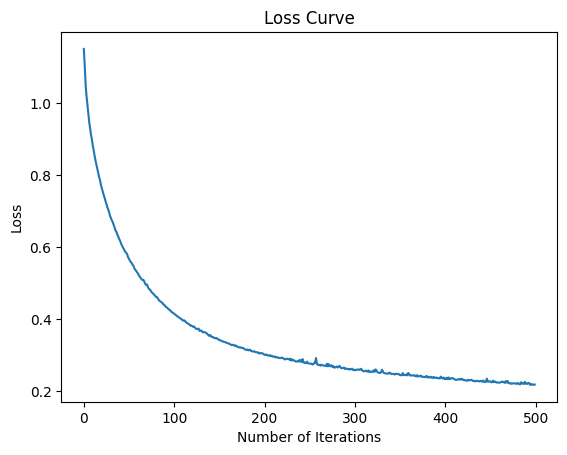

In [14]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

### 1.4.2 Hyper-parameter tuning (2 points)

Keep the values of the three hyper-paramters (`activation`, `solver`, and `max_iter`) as the same. For a better performance, we can consider to tune the following hyper-parameters

- `hidden_layer_sizes`
- `batch_size`
- `learning_rate_init`

**TODO**: Implement an MLPClassifier with the best hyper-parameter you have found. You can do use the grid search function from the demo code or write code to tune the hyper-parameters (e.g., picking a combination of the hyper-parameter values and the run the following code).

**NOTE**: Please do not use the GridSearchCV function from sklearn, as it only takes in one set of datapoints which it automatically splits itself. In our implementation, we want to take in both train and dev datasets so we can train the model with a certain set of hyperparameters and then evaluate it separately on the dev set.

Please report

- all combinations of hyper-parameters you have tried
- the corresponding training and development accuracies

Your results should have at least **eight** combinations.

**NOTE**: If you use the grid search function from the demo code, you will need to edit it to print out the accuracies of models trained with each set of hyperparameters.



In [15]:
# TODO: Code
# In our case The default values for the hyper-parameters are hidden_layer_sizes=(100,), batch_size=200, learning_rate_init=0.001

In [16]:
# First combination
# let's try increasing the hyper-parameter hidden_layer_sizes with more layers and more neurons to introduce more complexity and non-linearity in the model
NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(200, 200, 200), learning_rate_init=0.001, batch_size='auto')

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")
# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.8661588683351469
Dev accuracy: 0.4647058823529412


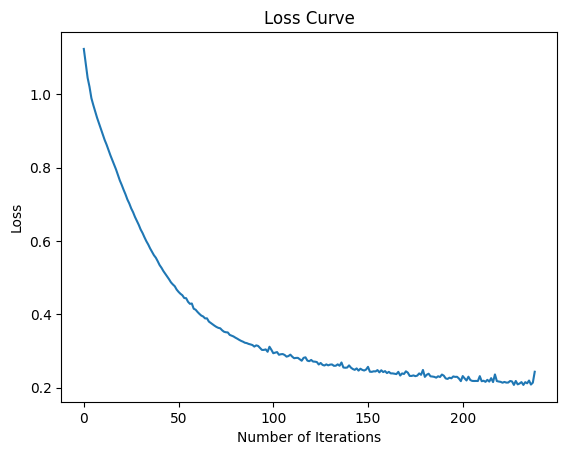

In [17]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [18]:
# Second combination
# the increase in the hidden_layer_sizes might have caused overfitting, let's try decreasing the hidden_layer_sizes to reduce the complexity of the model and also increase the learning_rate_init to speed up the convergence

NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(50, 50,50), learning_rate_init=0.01, batch_size='auto')

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9053318824809575
Dev accuracy: 0.4676470588235294


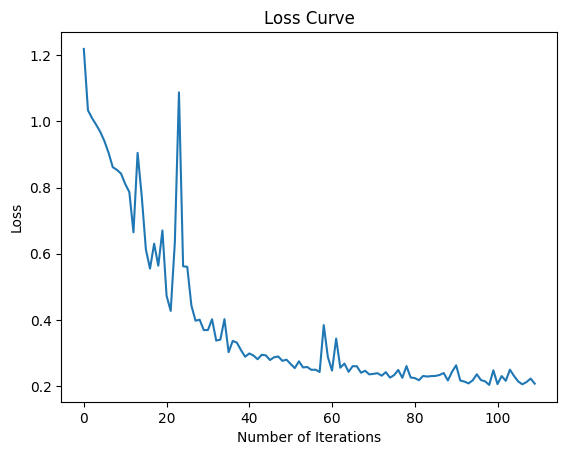

In [19]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [21]:
# third combination
# the learning_rate_init might have been too high, let's take it back to the default value and try reducing the batch_size

NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(50, 50,50), learning_rate_init=0.001, batch_size=100)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.8955386289445049
Dev accuracy: 0.4647058823529412


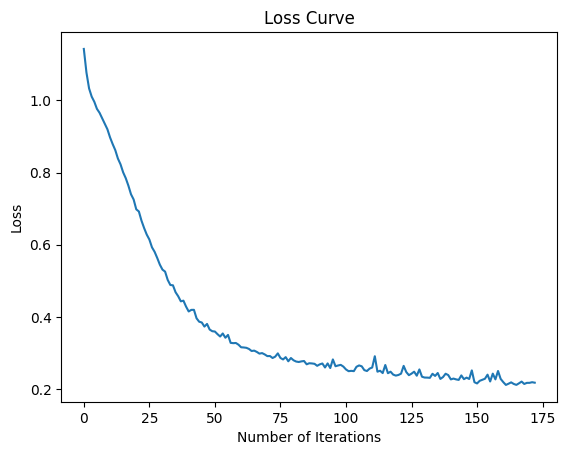

In [22]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [23]:
# fourth combination
# let us try further reducing the batch_size to 32

NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(50, 50,50), learning_rate_init=0.001, batch_size=32)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9042437431991295
Dev accuracy: 0.4470588235294118


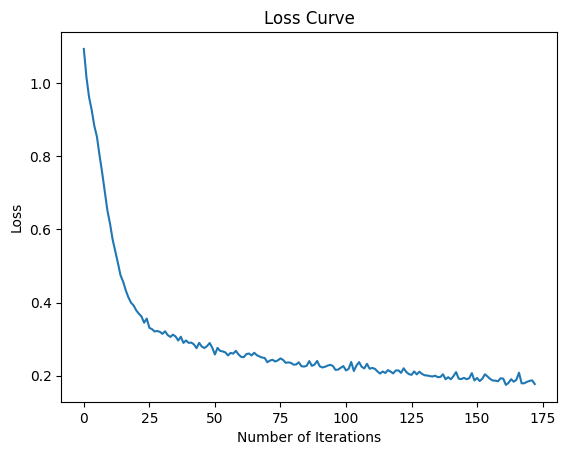

In [24]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [25]:
# fifth combination
# there is some noise in the loss curve in the end, this could mean that the model is struggling to reach the local minima, let's try to decrease the learning_rate_init to 0.0001

NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(50, 50,50), learning_rate_init=0.0001, batch_size=32)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9194776931447225
Dev accuracy: 0.4411764705882353


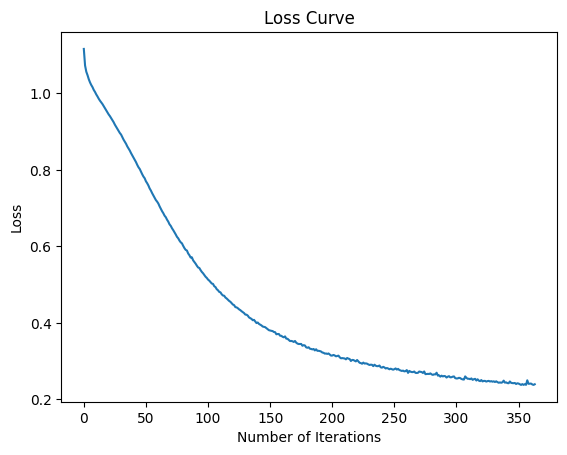

In [26]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [33]:
# sixth combination
# using the learning rate as 0.001 and setting batch size to 100
NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(50, 50,50), learning_rate_init=0.001, batch_size=100)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9075081610446137
Dev accuracy: 0.4588235294117647


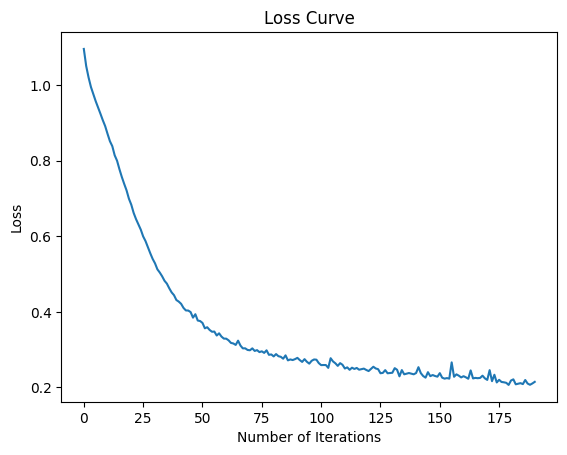

In [34]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [35]:
# seventh combination
# using the learning rate as 0.001 and using many hidden layers with 50 neurons in each layer
NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(50, 50,50,50,50,50,50,50,50,50), learning_rate_init=0.001, batch_size=32)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.8824809575625681
Dev accuracy: 0.46176470588235297


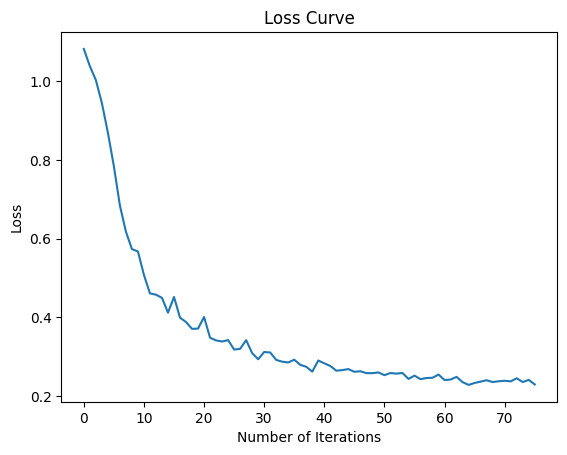

In [36]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [37]:
# eighth combination
# More number of hidden layers is probably not working because of our activation function, which causes the vanishing gradient problem
# let's try having only 2 layers with 200 neurons each and using adaptive learning rate with learning rate as 0.001 and batch_size as 32

NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(200, 200), learning_rate_init=0.001, batch_size=32)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")
# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.8966267682263329
Dev accuracy: 0.48823529411764705


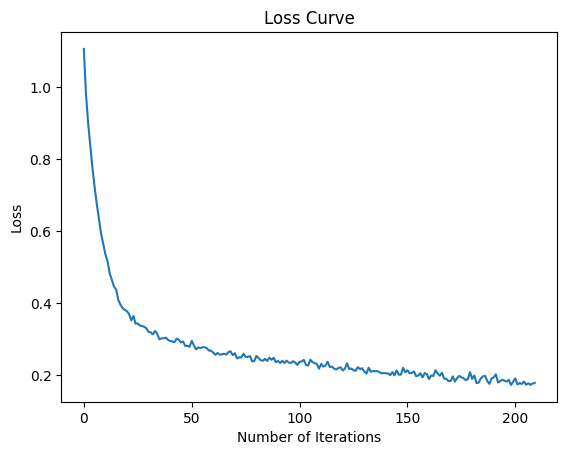

In [38]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()

In [39]:
# ninth combination
# let's try using only one layer with 200 neurons with learning rate as 0.001 and batch_size as 100

NN_classifier = MLPClassifier(activation='tanh', solver='sgd', max_iter=500, hidden_layer_sizes=(200), learning_rate_init=0.001, batch_size=100)

# fitting the model on the train matrix and train labels
NN_classifier.fit(train_matrix, train_labels)

# printing the classification accuracy on the train set
print(f"Train accuracy: {NN_classifier.score(train_matrix, train_labels)}")
# printing the classification accuracy on the dev set
print(f"Dev accuracy: {NN_classifier.score(dev_matrix, dev_labels)}")

Train accuracy: 0.9053318824809575
Dev accuracy: 0.45


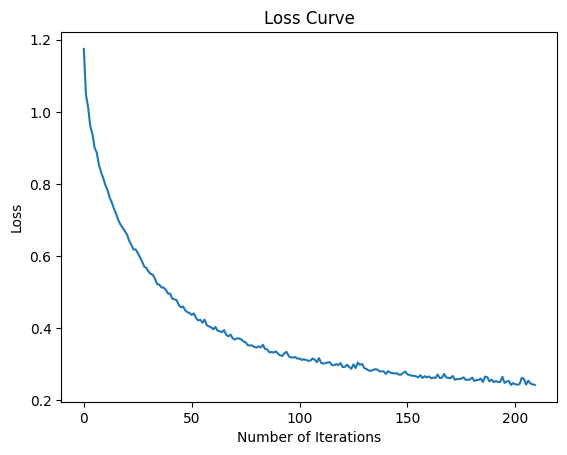

In [40]:
# displaying the loss curve
import matplotlib.pyplot as plt
plt.plot(NN_classifier.loss_curve_)
plt.xlabel('Number of Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()


### 1.4.3 Discussion (2 points)

TODO: Based on the results reported in section 1.4.2, answer the following questions

- among the three hyper-parameters, which one is most effective. Please justify your answer with the results.
- if there is a chance to pick one more combination, what values you would pick for these hyper-parameters? Please justify your answer using the appropriate machine learning knowledge.

Note that, it is important to justify your answer to get the full points.

- among the three hyper-parameters, which one is most effective. Please justify your answer with the results.  
Ans :- Among the three hyper-parameters, The one that seems to be the most effective is the hidden_layer_sizes hyper-parameter. This is because this hyper-parameter has the most significant impact on the model's performance. The hyper-parameter controls the complexity of our MLP model. The Neural Network with more hidden layers and more neurons in each layer is more complex and can capture more complex patterns in the data. However, if the model is too complex, it may overfit the training data. The model with fewer number of layers and neurons might not generalize to the data well. Therefore only the model with the correct number of layers and neurons might achieve optimum performance. In our case, the model with two hidden layers and 200 neurons in each layer achieved the best performance on the dev set. And among all the other hyper-parameters, this hyper-parameter seems to have the most significant performance because changing the other hyper-parameters such as learning_rate_init and batch_size did not have a significant impact in improving the model's performance as evidenced by the results, the learning rate parameter only effected the convergence speed of the model and the batch size parameter only effected amount of noise in the loss curve. However they did not make a change in the model's performance.
- if there is a chance to pick one more combination, what values you would pick for these hyper-parameters? Please justify your answer using the appropriate machine learning knowledge.  
Ans :- If I had to pick one more combination, I would try using the hidden_layer_sizes hyper-parameter with a value of (100, 100) with the learning_rate_init hyper-parameter set to 0.001 and the batch_size hyper-parameter set to 32. This is because the model with two hidden layers and 100 neurons in each layer might be able to capture patterns in the data than the model with 2 hidden layer and 200 neurons without overfitting too much. The learning_rate_init hyper-parameter is set to 0.001 because it seems to be the optimal learning rate for the model to converge to the local minima. The batch_size hyper-parameter is set to 32 because it seems to be the optimal batch size for the model to converge to the local minima without too much noise in the loss curve(Fourth Combination). The model with these hyper-parameters might achieve good performance on the dev set.

# Part II: Multi-choice Question Answering (7 points)



In this question, you will implement a text classifier for the question answering task from scratch, although most of the coding part will be similar to the previous question.

We will use the [AI2 ARC Easy](https://huggingface.co/datasets/allenai/ai2_arc/viewer/ARC-Easy) dataset for this question. Each of the data entry has four fields

- `id`
- `question`
- `choices`
    - `text`: all answer choices
    - `label`: the corresponding labels
- `answerKey`: the correct answer

The whole pipeline of building the classifier will be broken down a few steps. Please follow the instructions in each step for your implementation.

In [7]:
# Download the data
from datasets import load_dataset
arceasy_dataset = load_dataset("allenai/ai2_arc", 'ARC-Easy')

print(arceasy_dataset["train"][0])

{'id': 'Mercury_7220990', 'question': 'Which factor will most likely cause a person to develop a fever?', 'choices': {'text': ['a leg muscle relaxing after exercise', 'a bacterial population in the bloodstream', 'several viral particles on the skin', 'carbohydrates being digested in the stomach'], 'label': ['A', 'B', 'C', 'D']}, 'answerKey': 'B'}


## 2.1 Data Pre-processing (2 points)

In this part, we will construct the question-answering examples we will need to train the model. Each item in the AI2 ARC Easy dataset contains a question and all of its possible answer choices. If we were prompting a large language model, we would probably be able to create one input string that includes the question and all of its answer choices. However, as we discussed in class, simple text classifiers cannnot understand complex input/output relations. So we need the pre-processing step to re-format the datasets, such that the task of question answering can be solved as a classification task.

One option we discussed in class is to formulate the question-answering task as a set of binary classification task for each question. This means that each input datapoint must have an associated binary label (0/1). To transform the original dataset into this format, we construct an example for each (question, answer_choice) pair listed for a particular question. The example will consist of:

1. an input string and
2. a binary output label (0 or 1)

For each answer choice, the input string will be a concatenation of the question with that answer choice. The corresponding output label will be 1 if the input contains the correct answer choice and 0 if it does not.

**Example: {"question": "Which of these colors is a primary color?", "answer_choices": ["red", "purple", "pink", "green"]}**


Our method will construct four separate datapoints from this example. Their inputs will look like this:

1. "Which of these is a primary color? red"
2. "Which of these is a primary color? purple"
3. "Which of these is a primary color? pink"
4. "Which of these is a primary color? green"

The correct answer for the question above is "red", so we assign the label 1 to "red" and 0 to all the other answer choices (we use dictionary notation here just for clarity - in the code implementation, all input strings and all output labels will be stored in separate lists):

1. {input: "Which of these is a primary color? red", label: 1}
2. {input: "Which of these is a primary color? purple", label: 0}
3. {input: "Which of these is a primary color? pink", label: 0}
4. {input: "Which of these is a primary color? green", label: 0}


**TODO**

- Please select some fields from the ARC Easy dataset, and follow the instruction to construct the input/output pairs for each questions
- Convert both the `train` and `validation` to the corresponding format

**IMPORTANT**: Not all questions in the dataset will have the same number of answer choices. Please account for this in your implementation.

Please report

- All input/output pairs for the first question in the training set
- The size of the training and validation sets
- Your justification about why these fields are necessary for input and output

In [8]:
# TODO: Code

X_train = []
y_train = []
X_val = []
y_val = []

for i in range(len(arceasy_dataset["train"])):

    question = arceasy_dataset["train"][i]["question"]
    answer_choices = arceasy_dataset["train"][i]["choices"]["text"]
    label = arceasy_dataset["train"][i]["choices"]["label"]
    correct_answer = arceasy_dataset["train"][i]["answerKey"]

    for j in range(len(answer_choices)):
        X_train.append(f"{question} {answer_choices[j]}")
        y_train.append(int(label[j] == correct_answer))

for i in range(len(arceasy_dataset["validation"])):
    question = arceasy_dataset["validation"][i]["question"]
    answer_choices = arceasy_dataset["validation"][i]["choices"]["text"]
    label = arceasy_dataset["validation"][i]["choices"]["label"]
    correct_answer = arceasy_dataset["validation"][i]["answerKey"]

    for j in range(len(answer_choices)):
        X_val.append(f"{question} {answer_choices[j]}")
        y_val.append(int(label[j] == correct_answer))

# printing the input/output pairs for the first question in the training set
print(f"Input/Output pairs for the first question in the training set:")
for i in range(4):
    print(f"Input: {X_train[i]}, Output: {y_train[i]}")
    
# printing the size of the training and validation sets
print(f"Size of the training set: {len(X_train)}")
print(f"Size of the validation set: {len(X_val)}")

Input/Output pairs for the first question in the training set:
Input: Which factor will most likely cause a person to develop a fever? a leg muscle relaxing after exercise, Output: 0
Input: Which factor will most likely cause a person to develop a fever? a bacterial population in the bloodstream, Output: 1
Input: Which factor will most likely cause a person to develop a fever? several viral particles on the skin, Output: 0
Input: Which factor will most likely cause a person to develop a fever? carbohydrates being digested in the stomach, Output: 0
Size of the training set: 9002
Size of the validation set: 2281


Your justification

The fields that are selected are question text,choice text, label and the answer key. The question text is necessary for the input because it contains the question that needs to be answered. The choice text is necessary for the input because it contains the answer choices that need to be classified. The label is necessary for the input because it contains the correct answer choice for the question. The answer key is necessary for the input because it contains the correct answer for the question our of all the labels. The input/output pairs are constructed in such a way that the input is the question concatenated with each answer choice text and the output is 1 if the answer choice is the correct answer and 0 otherwise. This way the model can learn to classify the correct answer choice for the question as explained in class.

## 2.2 Tokenization (1 point)


**TODO**

- Use the defined tokenizer from Part I
- Create the vocab by
    - filtering out the tokens with their frequencies less than 3
    - converting all words to lower cases
- Convert both the `train` and `validation` sets to data matrices using the constructed vocab

Please report

- the number of words in the vocab
- the dimensions of the two data metrices constructed in the previous steps

In [9]:
# TODO: Code

from sklearn.feature_extraction.text import CountVectorizer

from spacy.lang.en import English
nlp = English()

def tokenizer(s):
    tokenize = nlp.tokenizer
    return [token.text for token in tokenize(s)]

# initiating the CountVectorizer Object
vectorizer = CountVectorizer(tokenizer=tokenizer, min_df=3, lowercase=True)

# fitting the vectorizer on the train_texts
vectorizer.fit(X_train)

# transforming the train_texts
train_matrix = vectorizer.transform(X_train)

# transforming the dev_texts
dev_matrix = vectorizer.transform(X_val)

# printing the number of words in the vocab
print(f"Number of words in the vocab: {len(vectorizer.get_feature_names_out())}")

# printing the dimensions of the two data matrices
print(f"Train matrix shape: {train_matrix.shape}")
print(f"Dev matrix shape: {dev_matrix.shape}")

/Users/parzival979/miniconda3/envs/NLP_Assignments/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Number of words in the vocab: 4951
Train matrix shape: (9002, 4951)
Dev matrix shape: (2281, 4951)


## 2.3 Build a Classifier (1 point)

Similar to the previous part, please build a classifier and train a classification model with the datasets created in section 2.2.

Note that, you can choose either logistic regression classifier or the MLP classifier, and you don't have to use both of them for this part.

**TODO**

- Build a classifier with the training set constructed above.

In [10]:
# TODO: Code

from sklearn.linear_model import LogisticRegression

# initiating the Logistic Regression Classifier

lr = LogisticRegression(penalty='l2', C=1/100, solver='liblinear', fit_intercept=True, max_iter=1000)

# fitting the model on the train matrix and train labels
lr.fit(train_matrix, y_train)

# printing the classification accuracy on the train set
print(f"Train accuracy: {lr.score(train_matrix, y_train)}")

# printing the classification accuracy on the dev set
print(f"Dev accuracy: {lr.score(dev_matrix, y_val)}")

Train accuracy: 0.7499444567873805
Dev accuracy: 0.7501096010521701


## 2.4 Accuracy of Question Answering (3 points)

If we use the classification accuracy as the measure of the model's question answering performance, it can be misleading. For example, consider the question in section 2.1

|Input | Output | Predicted Label|
|:---|:---|:---|
|"Which of these is a primary color? red" | True | False |
|"Which of these is a primary color? purple"| False | True |
|"Which of these is a primary color? pink" | False | False |
|"Which of these is a primary color? green" | Fasle | False |

If we measure the performance with the binary classification accuracy, the accuracy for this example group is 50%. However, if we measure the accuracy regarding the question answering performance, it is 0, because the model gives the wrong answer about the question. Therefore, to measure the performance of question answering, the evaluation metric has to aggregrate all predictions regarding the same question.

One further question is what if in the above example, a model gives two true prediction (e.g., instead of `False` on the first example, it predicts `True`). To avoid cases like this, we need to pick the final prediction based on the prediction probability on $$p(y=True|x).$$ For example,

|Input | Output | Predicted Probability $p(y=True|x)$|
|:---|:---|:---|
|"Which of these is a primary color? red" | True | 60% |
|"Which of these is a primary color? purple"| False | 90% |
|"Which of these is a primary color? pink" | False | 10% |
|"Which of these is a primary color? green" | Fasle | 20% |

With the given prediction probabilities, we should still consider the model prediction is `purple` (90%) instead of `red` (60%).


**TODO**

- Please follow the description above and implement the accuracy evaluation on question answering
    - Note that questions in this datasets may have different numbers of answer choices.
- Adjust the hyper-parameters of the classifier used in section 2.3, and make sure it can produce a good performance.


Please report

- The final prediction accuracies on both the training and the validation sets.

In [11]:
import numpy as np

# TODO: Your evaluation function

# getting the predicted probabilities for the train set
train_pred_prob = lr.predict_proba(train_matrix)

# getting the predicted probabilities for the dev set
dev_pred_prob = lr.predict_proba(dev_matrix)

# initializing the final predictions for the train set
train_final_pred = []
# initializing the final predictions for the dev set
dev_final_pred = []

# initializing an empty list to store the correct choices
correct_choice_train = []
# putting the correct choice of the train set in the correct_choice_train list by iterating through the train set
for i in range(len(arceasy_dataset["train"])):
    correct_choice_train.append(arceasy_dataset["train"][i]['answerKey'])

# initializing an empty list to store the correct choices
correct_choice_dev = []
# putting the correct choice of the dev set in the correct_choice_dev list by iterating through the dev set
for i in range(len(arceasy_dataset["validation"])):
    correct_choice_dev.append(arceasy_dataset["validation"][i]['answerKey'])


current_num = 0
# iterating through the train set
for i in range(len(arceasy_dataset["train"])):
    # getting the number of answer choices for the question
    num_choices = len(arceasy_dataset["train"][i]["choices"]["text"])
    # getting the predicted probabilities for the question
    prob = train_pred_prob[current_num: current_num + num_choices]
    # getting the index of the answer choice with the highest probability
    final_pred = np.argmax(prob[:, 1])
    # appending the final prediction to the final predictions list
    train_final_pred.append(arceasy_dataset["train"][i]["choices"]["label"][final_pred])
    current_num += num_choices

# initializing the final predictions for the dev set
current_num = 0
for i in range(len(arceasy_dataset["validation"])):
    # getting the number of answer choices for the question
    num_choices = len(arceasy_dataset["validation"][i]["choices"]["text"])
    # getting the predicted probabilities for the question
    prob = dev_pred_prob[current_num: current_num + num_choices]
    # getting the index of the answer choice with the highest probability
    final_pred = np.argmax(prob[:, 1])
    # appending the final prediction to the final predictions list
    dev_final_pred.append(arceasy_dataset["validation"][i]["choices"]["label"][final_pred])
    current_num += num_choices

In [12]:
# TODO: Evaluate the classifier and report the results

# using sklearn's accuracy_score to calculate the accuracy
from sklearn.metrics import accuracy_score

# calculating the accuracy on the train set
train_accuracy = accuracy_score(correct_choice_train, train_final_pred)

# calculating the accuracy on the dev set
dev_accuracy = accuracy_score(correct_choice_dev, dev_final_pred)

print(f"Train accuracy: {train_accuracy}")
print(f"Dev accuracy: {dev_accuracy}")

Train accuracy: 0.5228787205686362
Dev accuracy: 0.32105263157894737


**End of the homework 01**

---